# Anisotropy in 2D  

This tutorial illustrates how fiber rotation influences wave propagation speed in different directions.  

## Overview  

- **Tissue:** 2D grid of size `400 × 400`  or ``256 x 256`` 
- **Models:**  
  - Aliev–Panfilov  
  - Courtemanche  
- **Stimulation:** Apply `u = 1.0` at the center of the tissue  
- **Plots:**  
  - Activation wave  
  - Major and minor axes of the ellipse fitted to the activation wave  
  - Orientation angle of the ellipse  
  - Maximum and minimum values of `u`

## Reference

For numeric schemes refer to:
"Bram van Es, Barry Koren, Hugo J. de Blank,
Finite-difference schemes for anisotropic diffusion,
Journal of Computational Physics,
Volume 272,
2014,
Pages 526-549,
ISSN 0021-9991,
https://doi.org/10.1016/j.jcp.2014.04.046."

### Isotropic Conduction  

By default, if no fiber orientation is provided, isotropic conduction is assumed.  

In this example, we used:  
- Conductivity = `1.0`  
- Conductivity = `0.5` for half of the tissue  
- Conductivity = `0.5`  

Running AlievPanfilov on [400, 400] Grid: 100%|██████████| 3000/3000 [00:01<00:00, 2292.79it/s]


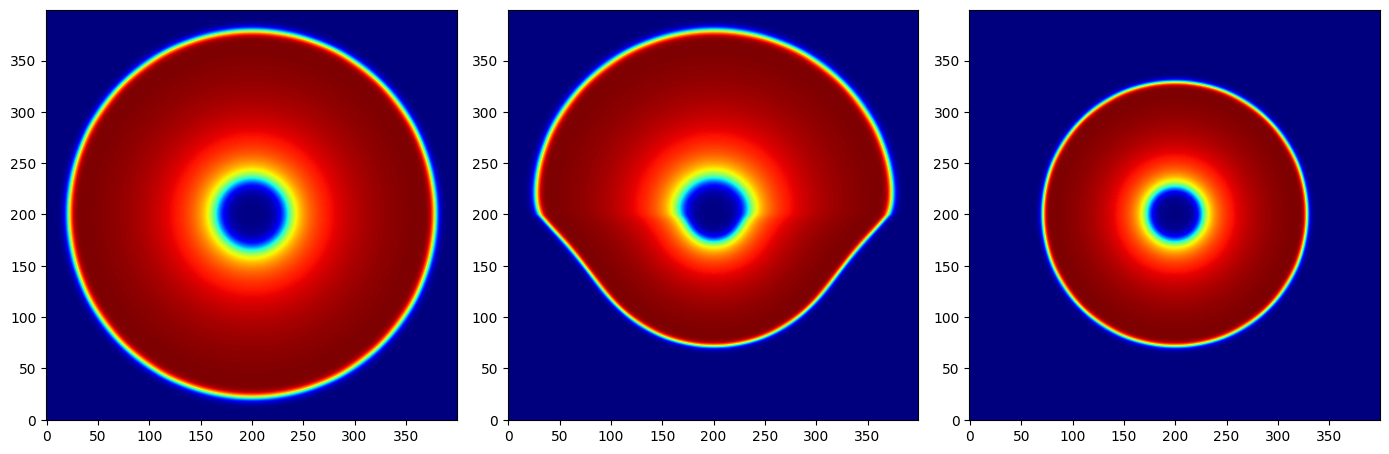

In [18]:

import matplotlib.pyplot as plt
import numpy as np

import finitewave as fw


# number of nodes on the side
n = 400

images = []
for c, n_max in zip([1, 0.5, 0.5], [-1, n//2, -1]):
    tissue = fw.CardiacTissue([n, n], dr=0.25)
    tissue.conductivity = np.ones((n, n))
    tissue.conductivity[:n_max, :] = c

    diffusion_model = fw.GridDiffusionModel()
    diffusion_model.stencil = fw.IsotropicStencil()

    # set up stimulation parameters:
    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                               x_min=n//2 - 3, x_max=n//2 + 3,
                                               y_min=n//2 - 3, y_max=n//2 + 3))

    simulation = fw.CardiacSimulation()
    simulation.dt = 0.01
    simulation.t_max = 30
    # add the tissue and the stim parameters to the model object:
    simulation.cardiac_tissue = tissue
    simulation.cardiac_model = fw.AlievPanfilov()
    simulation.stim_sequence = stim_sequence
    simulation.diffusion_model = diffusion_model

    # run the model:
    simulation.run()
    images.append(simulation.cardiac_model.output("u"))


fig, axs = plt.subplots(ncols=len(images), figsize=(14, 7))

for i in range(len(images)):
    axs[i].imshow(images[i], origin='lower', cmap='jet')

plt.tight_layout()

# Anisotropic Conduction  

If fibers (a matrix of normalized vectors) are provided, the model need to
use specific stencil.

This section demonstrates how the wave propagates for different fiber angles.


1. Helper function to run models and plot the results
- Conduction velocity (CV) along and across the fibers is calculated based on  
  the semi-major and semi-minor axes of the ellipses.

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
import finitewave as fw


def run_simulation(alpha, n, dt, dr, t_max, stencil, model, model_step=1,
                   fib_dens=0.0):
    tissue = fw.CardiacTissue([n, n], dr=dr)
    tissue.mesh += (np.random.random(tissue.mesh.shape) < fib_dens).astype(int)
    # add fibers orientation vectors
    tissue.fibers = np.zeros([n, n, 2])
    tissue.fibers[:, :, 0] = np.cos(alpha)
    tissue.fibers[:, :, 1] = np.sin(alpha)

    diffusion_model = fw.GridDiffusionModel()
    diffusion_model.stencil = stencil

    # set up stimulation parameters:
    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                               x_min=n//2 - 3, x_max=n//2 + 3,
                                               y_min=n//2 - 3, y_max=n//2 + 3))

    simulation = fw.CardiacSimulation(backend="mlx")
    simulation.dt = dt
    simulation.t_max = t_max
    # add the tissue and the stim parameters to the model object:
    simulation.cardiac_tissue = tissue
    simulation.cardiac_model = model
    simulation.cardiac_model.step = model_step
    simulation.stim_sequence = stim_sequence
    simulation.diffusion_model = diffusion_model

    # run the model:
    simulation.run()

    u = simulation.cardiac_model.output("u")
    return u
    

def calc_properties(alpha, u, dr, t_max):
    # calculate properties of the wave
    labeled = (u > 0.1).astype(int)

    props = ski.measure.regionprops_table(
        labeled, properties=('orientation', 'major_axis_length', 'minor_axis_length')
        )
    
    cv_along = props['major_axis_length'] * dr / (2 * t_max)
    cv_across = props['minor_axis_length'] * dr / (2 * t_max)
    orientation = props['orientation']
    out_props = [alpha, orientation[0], cv_along[0], cv_across[0]]
    return out_props


def plot_anisotropy_vs_angle(images, measures):

    fig, axs = plt.subplot_mosaic([[f'{i}' for i in range(7)],
                               ['cv'] * 2 + ['axis_ratio'] * 2 + ['orientation'] * 3],
                               figsize=(14, 7))
    alphas = np.degrees(measures[:, 0])
    orientations = np.degrees(measures[:, 1])
    orientations = np.where(orientations < -45, orientations + 180, orientations)
    cv_along = measures[:, 2]
    cv_across = measures[:, 3]
    axis_ratio = cv_along / cv_across

    for i in range(len(alphas)):
        ax = axs[f'{i}']
        ax.imshow(images[i], cmap='jet', origin='lower')
        ax.set_title(f'alpha: {alphas[i]:.0f}°')

    ax = axs['cv']
    ax.plot(alphas, cv_along, 'o-', label='Along')
    ax.plot(alphas, cv_across, 'o-', label='Across')
    ax.set_xlabel('Fibers orientation (alpha)')
    ax.set_ylabel('CV')
    ax.set_xticks(alphas)
    ax.grid(True)
    ax.legend()

    ax = axs['axis_ratio']
    ax.plot(alphas, axis_ratio, 'o-')
    ax.set_xlabel('Fibers orientation (alpha)')
    ax.set_ylabel('CV along / CV across')
    ax.set_xticks(alphas)
    ax.set_ylim(1, axis_ratio.max() + 0.5)
    ax.grid(True)

    ax = axs['orientation']
    ax.plot(alphas, orientations, 'o-')
    ax.set_xlabel('Fibers orientation (alpha)')
    ax.set_ylabel('Wave orientation')
    ax.set_xticks(alphas)
    ax.set_yticks(alphas)
    ax.grid(True)

    plt.tight_layout()
    plt.show()

2. Run model with default ``AsymmetricStencil``

Running AlievPanfilov on [400, 400] Grid: 100%|██████████| 3000/3000 [00:00<00:00, 4637.57it/s]


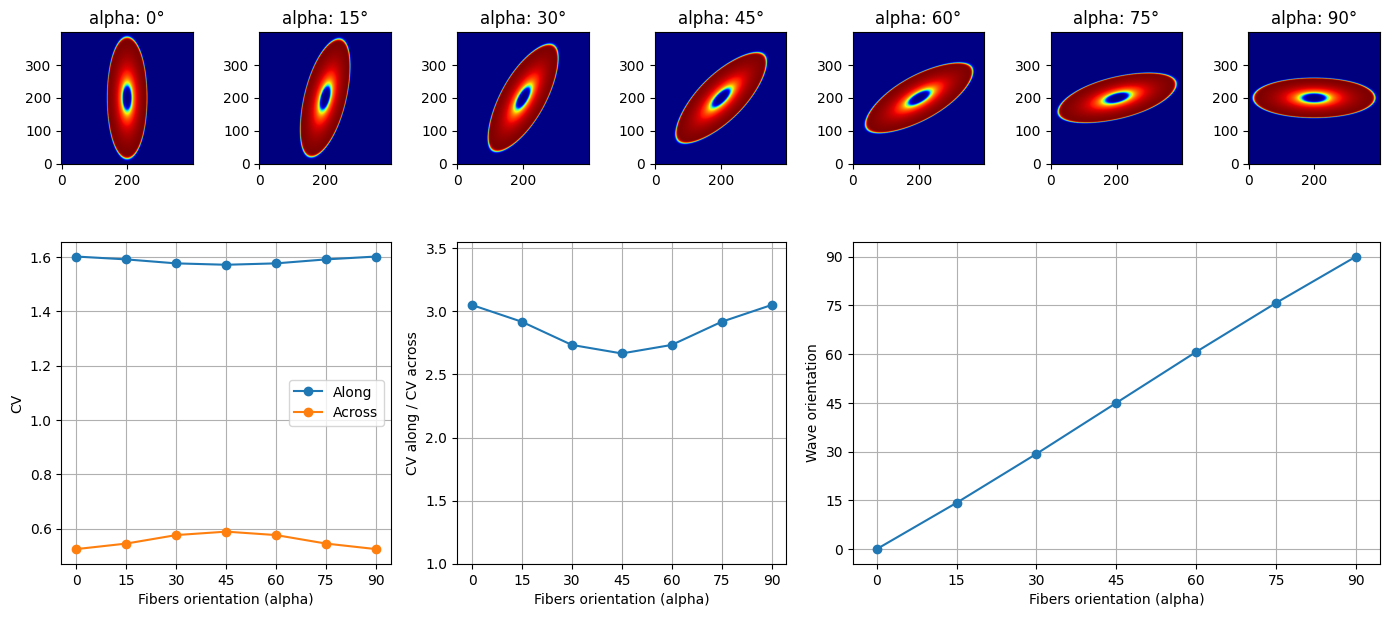

In [35]:
import matplotlib.pyplot as plt
import numpy as np

import finitewave as fw


# number of nodes on the side
n = 400
dt = 0.01
dr = 0.25
t_max = 30

alphas = np.radians(np.arange(0, 91, 15))
model = fw.AlievPanfilov()
stencil = fw.AsymmetricStencil()

measures_asymmetric = []
images_asymmetric = []
for alpha in alphas:
    u = run_simulation(alpha, n, dt, dr, t_max, stencil, model, model_step=1)
    props = calc_properties(alpha, u, dr, t_max)
    images_asymmetric.append(u)
    measures_asymmetric.append(props)

measures_asymmetric = np.array(measures_asymmetric)

plot_anisotropy_vs_angle(images_asymmetric, measures_asymmetric)

## Effect of Fibrosis on Anisotropy

This section explores the impact of fibrosis on the anisotropy of wave propagation in cardiac tissue. By introducing fibrosis into the tissue model, we can observe changes in wave speed and directionality. The simulations are performed for different fiber orientations (alpha values), and the resulting wave properties, such as orientation, axis lengths, and axis ratios, are analyzed to understand the effects of fibrosis on anisotropy.

Running AlievPanfilov on [400, 400] Grid: 100%|██████████| 4000/4000 [00:00<00:00, 5769.22it/s]


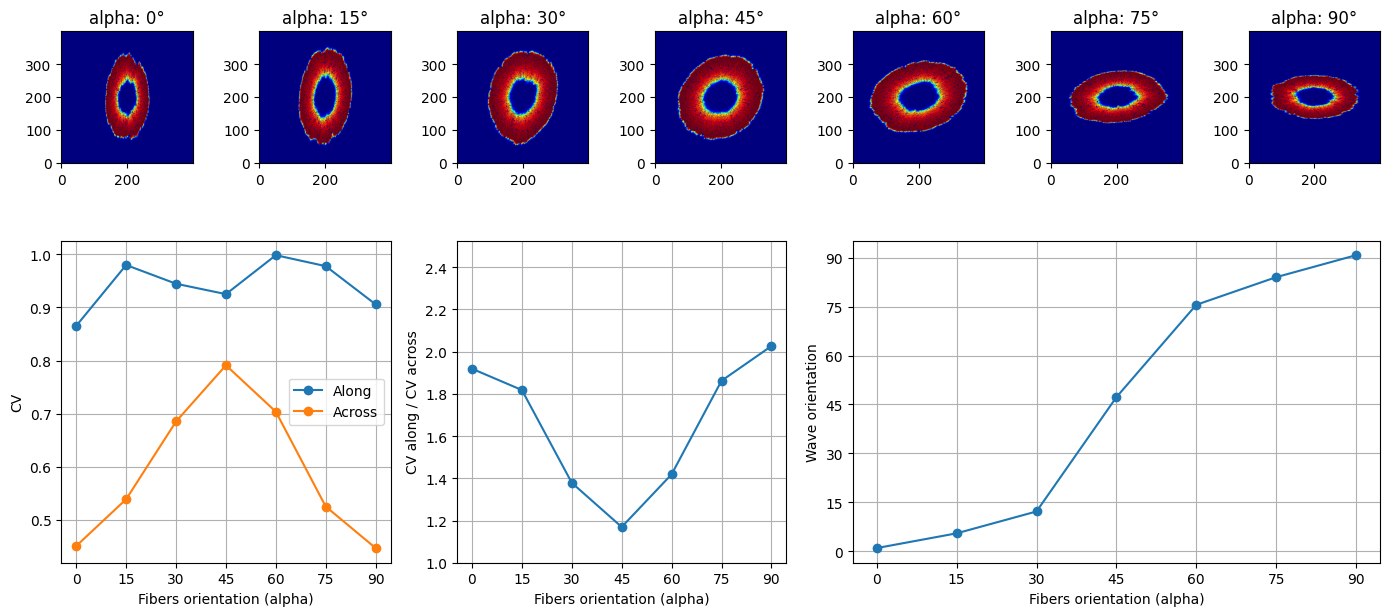

In [43]:

import matplotlib.pyplot as plt
import numpy as np

import finitewave as fw


# number of nodes on the side
n = 400
dt = 0.01
dr = 0.25
t_max = 40

alphas = np.radians(np.arange(0, 91, 15))
model = fw.AlievPanfilov()
stencil = fw.AsymmetricStencil()

measures_asymmetric_fibro = []
images_asymmetric_fibro = []

for alpha in alphas:
    u = run_simulation(alpha, n, dt, dr, t_max, stencil, model, model_step=1, fib_dens=0.2)
    props = calc_properties(alpha, u, dr, t_max)
    images_asymmetric_fibro.append(u)
    measures_asymmetric_fibro.append(props)

measures_asymmetric_fibro = np.array(measures_asymmetric_fibro)

plot_anisotropy_vs_angle(images_asymmetric_fibro, measures_asymmetric_fibro)

## Using Ionic Model

Running Courtemanche on [400, 400] Grid: 100%|██████████| 3000/3000 [00:02<00:00, 1278.20it/s]


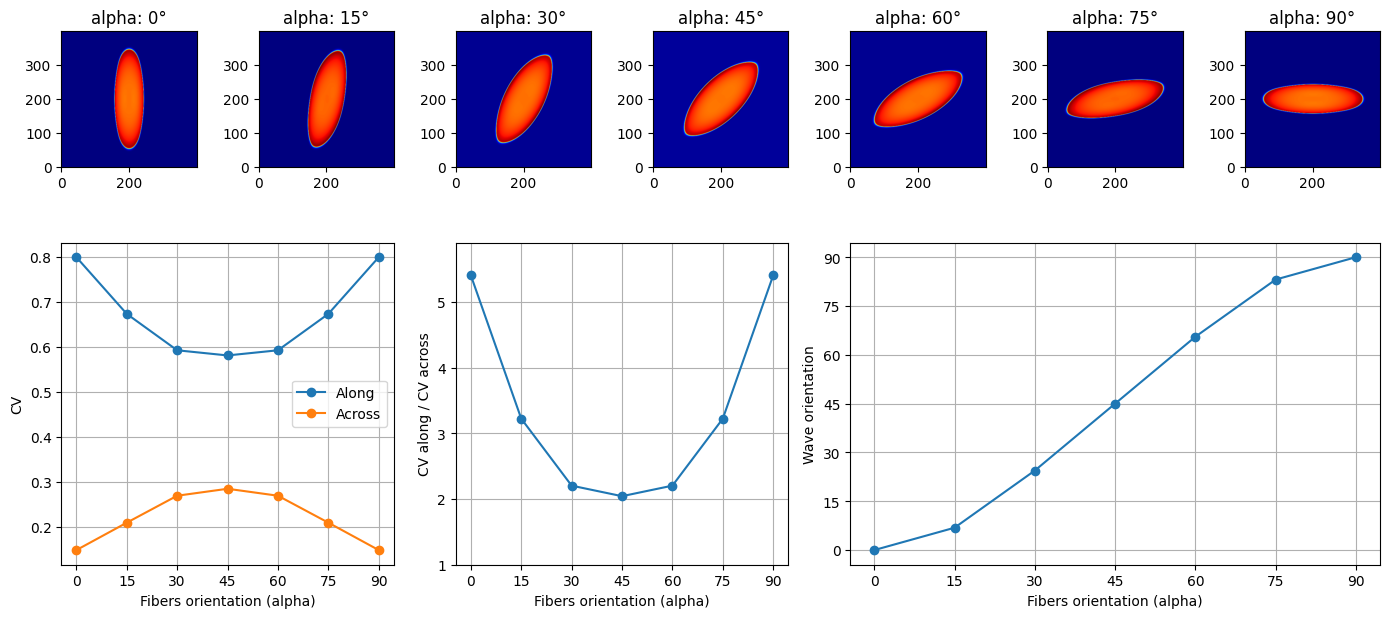

In [41]:
import matplotlib.pyplot as plt
import numpy as np

import finitewave as fw


# number of nodes on the side
n = 400
dt = 0.01
dr = 0.1
t_max = 30

alphas = np.radians(np.arange(0, 91, 15))
model = fw.Courtemanche()
model.D_model = 0.1
stencil = fw.AsymmetricStencil()

measures_asymmetric_ionic = []
images_asymmetric_ionic = []
for alpha in alphas:
    u = run_simulation(alpha, n, dt, dr, t_max, stencil, model, model_step=1, fib_dens=0.)
    props = calc_properties(alpha, u, dr, t_max)
    images_asymmetric_ionic.append(u)
    measures_asymmetric_ionic.append(props)

measures_asymmetric_ionic = np.array(measures_asymmetric_ionic)

plot_anisotropy_vs_angle(images_asymmetric_ionic, measures_asymmetric_ionic)

## Anisotropy in triangulated mesh

Running Courtemanche on Triangle Elements: 100%|██████████| 3000/3000 [00:09<00:00, 310.82it/s]


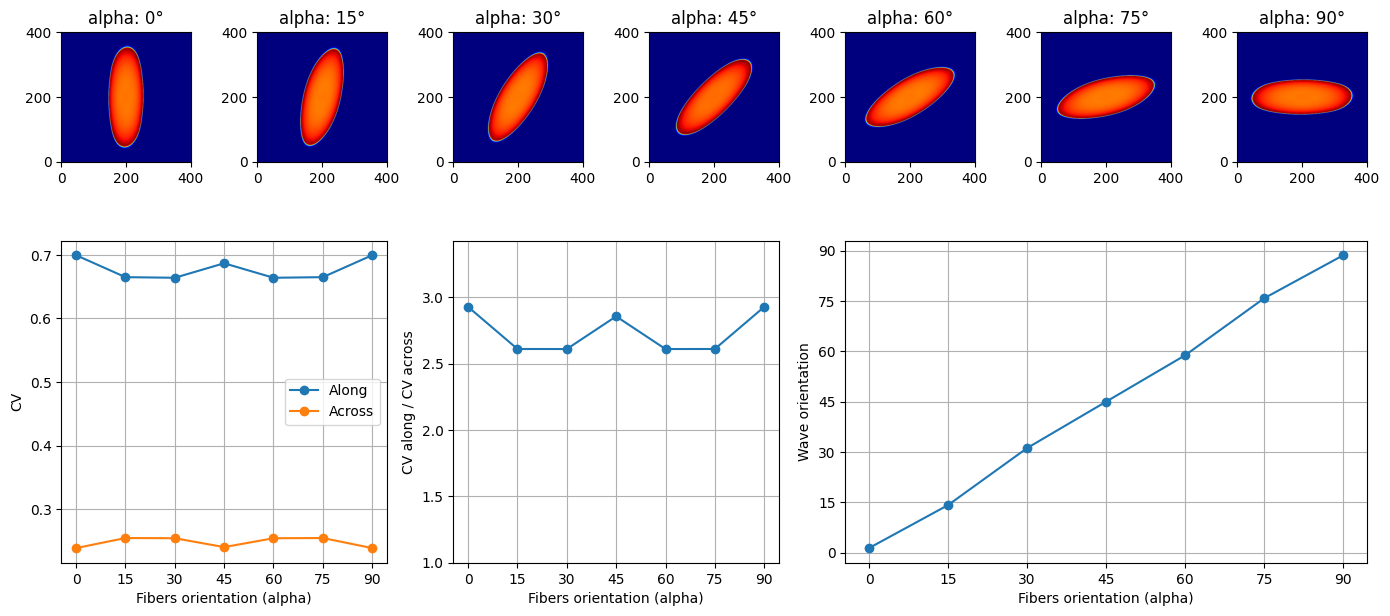

In [ ]:
import numpy as np

import finitewave as fw


def run_simulation_fem(alpha, coords, elems, dt, t_max, density=0.):
    model = fw.Courtemanche()
    model.D_model = 0.1

    tissue = fw.CardiacTissueElements(coords, elems, fw.ElementType.TRIANGLE)
    tissue.mesh_elems += (np.random.random(len(elems)) < density).astype(int)
    tissue.fibers = np.zeros([elems.shape[0], 2])
    tissue.fibers[:, 0] = np.cos(alpha)
    tissue.fibers[:, 1] = np.sin(alpha)

    simulation = fw.CardiacSimulation(backend="mlx")
    simulation.dt = dt
    simulation.t_max = t_max
    simulation.cardiac_tissue = tissue
    simulation.cardiac_model = model
    simulation.stim_sequence = fw.StimSequence()
    simulation.stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                                          x_min=size/2 - 0.3, x_max=size/2 + 0.3, 
                                                          y_min=size/2 - 0.3, y_max=size/2 + 0.3))
    simulation.run()

    u = simulation.cardiac_model.output("u").reshape(n+1, n+1).T
        
    return u


# number of nodes on the side
n = 400
size = 40
dr = size / n
dt = 0.01
t_max = 30
coords, elems = fw.build_triangulated_mesh(n, n, (0, size), (0, size))

measures_triangular = []
images_triangular = []

alphas = np.radians(np.arange(0, 91, 15))

for alpha in alphas:
    u = run_simulation_fem(alpha, coords, elems, dt, t_max)
    props = calc_properties(alpha, u, dr, t_max)
    images_triangular.append(u)
    measures_triangular.append(props)

measures_triangular = np.array(measures_triangular)
plot_anisotropy_vs_angle(images_triangular, measures_triangular)

Running Courtemanche on Triangle Elements: 100%|██████████| 3000/3000 [00:13<00:00, 216.68it/s]


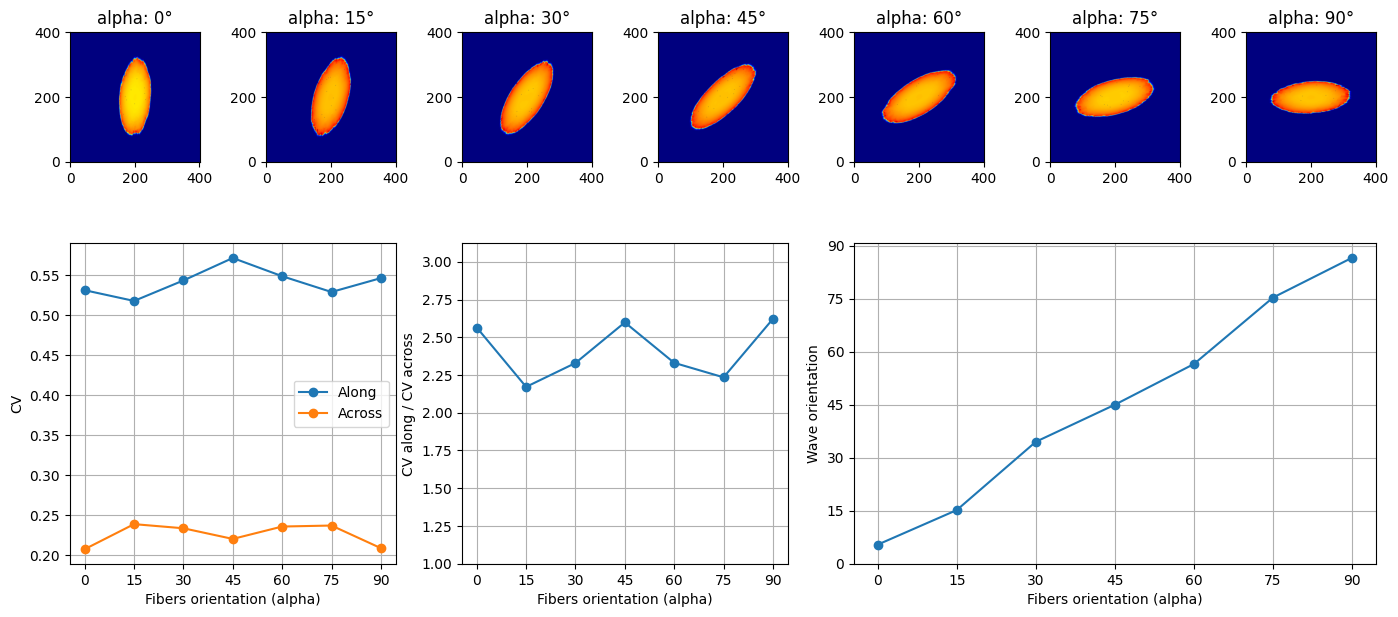

In [ ]:
import numpy as np

import finitewave as fw


# number of nodes on the side
n = 400
size = 40
dr = size / n
dt = 0.01
t_max = 30
coords, elems = fw.build_triangulated_mesh(n, n, (0, size), (0, size))

measures_triangular = []
images_triangular = []

alphas = np.radians(np.arange(0, 91, 15))

for alpha in alphas:
    u = run_simulation_fem(alpha, coords, elems, dt, t_max, density=0.3)
    props = calc_properties(alpha, u, dr, t_max)
    images_triangular.append(u)
    measures_triangular.append(props)

measures_triangular = np.array(measures_triangular)
plot_anisotropy_vs_angle(images_triangular, measures_triangular)